# 08/09/2026 (Loan Default Prediction)

### Problem statement
* The objective of this project is to build a machine learning classification model that predicts whether a customer is likely  to default on a loan

* The target variable is Loan_Default:
> 0 = No Default, 
> 1 = Default

### Logistic Regression

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("loan_default_dataset.csv")
df.head()

,Loan_ID,Customer_ID,Age,Employment_Type,Employment_Years,Education,Dependents,Annual_Income,Monthly_Income,Existing_Loan_Amount,...,Loan_Term_Months,Interest_Rate,Loan_Purpose,Collateral_Value,Previous_Loan_Count,Previous_Defaults,Late_Payments_12M,Credit_Card_Utilization,Credit_History_Years,Loan_Default
0,LN113916,CUST213916,53,SALARIED,11.0,Graduate,1.0,579000.0,48250,0,...,60,11.65,Education,0.0,1,0,0,0.16,5,0
1,LN109534,CUST209534,36,Contract,11.0,Graduate,0.0,708000.0,59000,0,...,300,8.75,Home,2895000.0,1,0,0,0.28,9,0
2,LN101359,CUST201359,43,Unemployed,0.0,Graduate,2.0,116600.0,9717,109500,...,36,15.35,Business,0.0,1,1,1,0.42,1,1
3,LN114956,CUST214956,64,Salaried,10.0,Post-Graduate,0.0,974400.0,81200,0,...,36,11.33,Personal,NaN,0,0,1,0.37,7,0
4,LN112181,CUST212181,45,Salaried,7.0,Post-Graduate,2.0,1020900.0,85075,394600,...,36,11.51,Personal,0.0,3,0,2,0.66,18,0


In [4]:
df.shape

(20045, 25)

In [5]:
df.columns

Index(['Loan_ID', 'Customer_ID', 'Age', 'Employment_Type', 'Employment_Years',
       'Education', 'Dependents', 'Annual_Income', 'Monthly_Income',
       'Existing_Loan_Amount', 'Existing_EMI', 'Credit_Score',
       'Savings_Balance', 'Debt_to_Income_Ratio', 'Loan_Amount',
       'Loan_Term_Months', 'Interest_Rate', 'Loan_Purpose', 'Collateral_Value',
       'Previous_Loan_Count', 'Previous_Defaults', 'Late_Payments_12M',
       'Credit_Card_Utilization', 'Credit_History_Years', 'Loan_Default'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20045 entries, 0 to 20044
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loan_ID                  20045 non-null  object 
 1   Customer_ID              20045 non-null  object 
 2   Age                      20045 non-null  int64  
 3   Employment_Type          20045 non-null  object 
 4   Employment_Years         19444 non-null  float64
 5   Education                19444 non-null  object 
 6   Dependents               19645 non-null  float64
 7   Annual_Income            19645 non-null  float64
 8   Monthly_Income           20045 non-null  int64  
 9   Existing_Loan_Amount     20045 non-null  int64  
 10  Existing_EMI             20045 non-null  int64  
 11  Credit_Score             19245 non-null  float64
 12  Savings_Balance          19043 non-null  float64
 13  Debt_to_Income_Ratio     19544 non-null  float64
 14  Loan_Amount           

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,20045.0,5.406475e+01,9.648290e+00,27.000,47.00,54.000,62.000,68.00
Employment_Years,19444.0,6.649815e+00,4.809398e+00,0.000,3.00,6.000,9.000,42.00
Dependents,19645.0,1.626368e+00,1.332242e+00,0.000,1.00,1.000,2.000,5.00
Annual_Income,19645.0,9.259777e+05,7.066996e+05,90000.000,524000.00,765600.000,1123200.000,9000000.00
Monthly_Income,20045.0,7.713088e+04,5.890371e+04,7500.000,43658.00,63792.000,93542.000,750000.00
Existing_Loan_Amount,20045.0,2.304307e+05,3.972973e+05,0.000,0.00,0.000,352000.000,8329400.00
Existing_EMI,20045.0,5.780771e+03,1.008788e+04,0.000,0.00,0.000,8594.000,183433.00
Credit_Score,19245.0,7.216193e+02,6.519051e+01,426.000,679.00,724.000,767.000,900.00
Savings_Balance,19043.0,2.121573e+05,3.270603e+05,1700.000,54900.00,114300.000,239400.000,7115700.00
Debt_to_Income_Ratio,19544.0,4.697155e-01,3.089922e-01,0.037,0.27,0.409,0.582,3.00


In [12]:
# Columns containing missing values
df.isnull().sum()[df.isnull().sum()>0]

Employment_Years            601
Education                   601
Dependents                  400
Annual_Income               400
Credit_Score                800
Savings_Balance            1002
Debt_to_Income_Ratio        501
Loan_Purpose                400
Collateral_Value            302
Credit_Card_Utilization     601
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(45)

In [14]:
df = df.drop_duplicates()

In [7]:
df.duplicated().sum()

np.int64(0)

In [15]:
df["Loan_Default"].value_counts()

Loan_Default
0    17357
1     2643
Name: count, dtype: int64

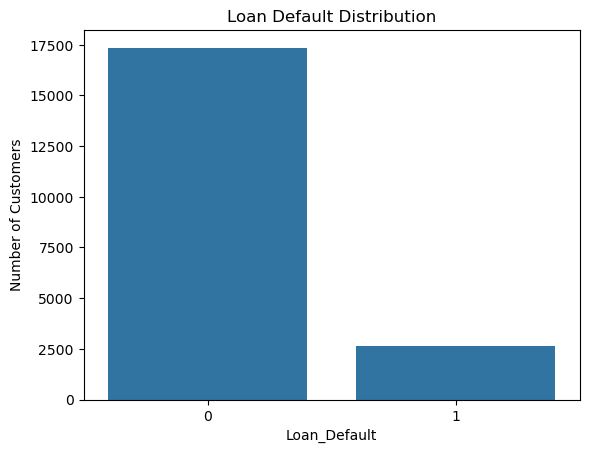

In [16]:
sns.countplot(x="Loan_Default",data=df)
plt.title("Loan Default Distribution")
plt.xlabel("Loan_Default")
plt.ylabel("Number of Customers")
plt.show()

In [17]:
categorical_columns = df.select_dtypes(include="object").columns
categorical_columns

Index(['Loan_ID', 'Customer_ID', 'Employment_Type', 'Education',
       'Loan_Purpose'],
      dtype='object')

In [18]:
numerical_columns = df.select_dtypes(include=np.number).columns
numerical_columns

Index(['Age', 'Employment_Years', 'Dependents', 'Annual_Income',
       'Monthly_Income', 'Existing_Loan_Amount', 'Existing_EMI',
       'Credit_Score', 'Savings_Balance', 'Debt_to_Income_Ratio',
       'Loan_Amount', 'Loan_Term_Months', 'Interest_Rate', 'Collateral_Value',
       'Previous_Loan_Count', 'Previous_Defaults', 'Late_Payments_12M',
       'Credit_Card_Utilization', 'Credit_History_Years', 'Loan_Default'],
      dtype='object')

In [19]:
df["Employment_Type"].value_counts()

Employment_Type
Salaried         9782
Self-Employed    3891
Business         2979
Contract         2002
Unemployed        993
SALARIED          207
self employed      84
business           62
Name: count, dtype: int64

In [20]:
df["Education"].value_counts()

Education
Graduate         7964
Post-Graduate    4571
High School      3105
Diploma          2726
Doctorate         789
graduate          175
Post Graduate      70
Name: count, dtype: int64

In [21]:
df["Loan_Purpose"].value_counts()

Loan_Purpose
Personal     5402
Home         4177
Auto         3949
Education    2397
Business     2356
Medical      1160
 Personal      86
HOME           73
Name: count, dtype: int64

In [22]:
df["Employment_Type"] = (
    df["Employment_Type"]
    .str.strip()
    .str.lower()
)

In [23]:
df["Employment_Type"].value_counts()

Employment_Type
salaried         9989
self-employed    3891
business         3041
contract         2002
unemployed        993
self employed      84
Name: count, dtype: int64

In [24]:
df["Education"] = (
    df["Education"]
    .str.strip()
    .str.lower()
)

In [25]:
df["Loan_Purpose"] = (
    df["Loan_Purpose"]
    .str.strip()
    .str.lower()
)

In [26]:
df["Education"].value_counts()

Education
graduate         8139
post-graduate    4571
high school      3105
diploma          2726
doctorate         789
post graduate      70
Name: count, dtype: int64

In [27]:
df["Loan_Purpose"].value_counts()

Loan_Purpose
personal     5488
home         4250
auto         3949
education    2397
business     2356
medical      1160
Name: count, dtype: int64

In [28]:
df["Employment_Type"] = df["Employment_Type"].str.replace(
    "self employed",
    "self-employed"
)

In [29]:
df["Employment_Type"].value_counts()

Employment_Type
salaried         9989
self-employed    3975
business         3041
contract         2002
unemployed        993
Name: count, dtype: int64

In [30]:
df["Education"] = df["Education"].str.replace(
    "post graduate",
    "post-graduate"
)

In [31]:
df["Education"].value_counts()

Education
graduate         8139
post-graduate    4641
high school      3105
diploma          2726
doctorate         789
Name: count, dtype: int64

In [32]:
df = df.drop(columns=['Loan_ID', 'Customer_ID'])

In [33]:
X = df.drop("Loan_Default",axis=1)
y = df["Loan_Default"]

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [36]:
print("Training Data = ",X_train.shape)
print("Testing Data = ",X_test.shape)

Training Data =  (16000, 22)
Testing Data =  (4000, 22)


In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder , StandardScaler

In [38]:
categorical_features = X_train.select_dtypes(include="object").columns
numerical_features = X_train.select_dtypes(include=np.number).columns

In [39]:
numeric_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

In [40]:
categorical_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])

In [41]:
preprocessor = ColumnTransformer([
    ("num",numeric_pipeline,numerical_features),
    ("cat",categorical_pipeline,categorical_features)
])

In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
logistic_model = Pipeline([
    ("preprocessor",preprocessor),
    ("model",LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [44]:
logistic_model.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [45]:
y_pred = logistic_model.predict(X_test)

In [46]:
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
classification_report,
confusion_matrix,
roc_auc_score
)

In [47]:
accuracy_score(y_test,y_pred)

0.735

In [48]:
precision_score(y_test,y_pred)

0.28708901363271855

In [49]:
recall_score(y_test,y_pred)

0.6767485822306238

In [50]:
f1_score(y_test,y_pred)

0.40315315315315314

In [51]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.74      0.83      3471
           1       0.29      0.68      0.40       529

    accuracy                           0.73      4000
   macro avg       0.61      0.71      0.62      4000
weighted avg       0.85      0.73      0.77      4000



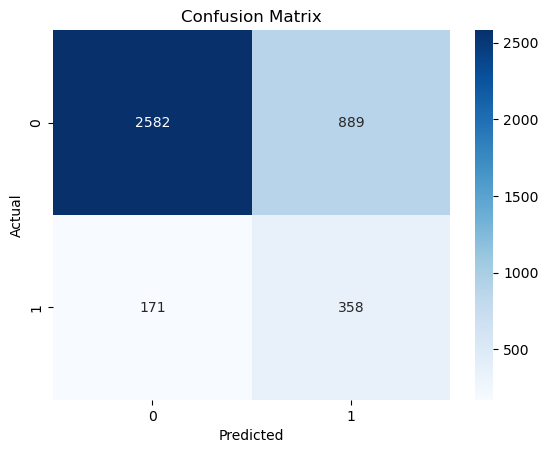

In [52]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [53]:
y_probability = logistic_model.predict_proba(X_test)[:,1]

In [54]:
roc_auc_score(y_test,y_probability)

0.7825825541252146

### Model created using Logistic Regression
##### Conclusion:
* Accuracy Score = 73.5
* F1 Score = 40.31
* ROC AUC Score = 78.25

### Decision Tree

In [55]:
from sklearn.tree import DecisionTreeClassifier

In [56]:
decision_tree = Pipeline([
    ("preprocessor",preprocessor),
    ("model",DecisionTreeClassifier(
        max_depth=6,
        random_state=42,
        class_weight="balanced"
    ))
])

In [57]:
decision_tree.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [58]:
dt_pred = decision_tree.predict(X_test)

In [59]:
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       0.93      0.72      0.81      3471
           1       0.25      0.63      0.36       529

    accuracy                           0.71      4000
   macro avg       0.59      0.67      0.59      4000
weighted avg       0.84      0.71      0.75      4000



### Model created using Decision Tree
##### Conclusion:
* Accuracy Score = 
* F1 Score = 
* ROC AUC Score = 

### Random Forest

In [60]:
from sklearn.ensemble import RandomForestClassifier

In [61]:
random_forest = Pipeline([
    ("preprocessor",preprocessor),
    ("model",RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])    

In [62]:
random_forest.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [63]:
rf_pred = random_forest.predict(X_test)

In [64]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93      3471
           1       0.63      0.05      0.09       529

    accuracy                           0.87      4000
   macro avg       0.75      0.52      0.51      4000
weighted avg       0.84      0.87      0.82      4000



#### Comparing models

In [65]:
def evaluate_model(model,X_test,y_test):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:,1]

    return {
        "Accuracy": accuracy_score(y_test,predictions),
        "Precision": precision_score(y_test,predictions),
        "Recall": recall_score(y_test,predictions),
        "F1 Score": f1_score(y_test,predictions),
        "ROC-AUC": roc_auc_score(y_test,probabilities),
    }    

In [66]:
results = []
for name,model in[
    ("Logistic Regression",logistic_model),
    ("Decision Tree",decision_tree),
    ("Random Forest",random_forest)
]:
    model.fit(X_train,y_train)

    metrics = evaluate_model(
        model,
        X_test,
        y_test
    )

    metrics["Model"] = name
    results.append(metrics)

In [67]:
results_df = pd.DataFrame(results)
results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Model
0,0.7350,0.287089,0.676749,0.403153,0.782583,Logistic Regression
1,0.7080,0.254797,0.627599,0.362445,0.726162,Decision Tree
2,0.8705,0.627907,0.051040,0.094406,0.757867,Random Forest


# 09/09/2026

### LightGBM

In [68]:
from lightgbm import LGBMClassifier

In [69]:
lightgbm_model = Pipeline([
    ("preprocessor",preprocessor),
    ("model",LGBMClassifier(
        n_estimator=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
        verbosity=-1
    ))
])

In [70]:
lightgbm_model.fit(
    X_train,y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [71]:
lgbm_pred = lightgbm_model.predict(X_test)

In [72]:
lgbm_probability = (
    lightgbm_model.predict_proba(X_test)[:,1])

In [73]:
print(classification_report(
    y_test,lgbm_pred
)
     )

              precision    recall  f1-score   support

           0       0.93      0.78      0.85      3471
           1       0.30      0.63      0.40       529

    accuracy                           0.76      4000
   macro avg       0.62      0.70      0.63      4000
weighted avg       0.85      0.76      0.79      4000



In [74]:
print("ROC-AUC: ",roc_auc_score(
    y_test,
    lgbm_probability
)
     )

ROC-AUC:  0.7668976379496546


In [75]:
def evaluate_model(model,X_test,y_test):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:,1]

    return {
        "Accuracy": accuracy_score(y_test,predictions),
        "Precision": precision_score(y_test,predictions),
        "Recall": recall_score(y_test,predictions),
        "F1 Score": f1_score(y_test,predictions),
        "ROC-AUC": roc_auc_score(y_test,probabilities),
    }    

In [76]:
models = [
    ("Logistic Regression",logistic_model),
    ("Decision Tree",decision_tree),
    ("Random Forest",random_forest),
    ("LightGBM",lightgbm_model)
]

results = []
for name,model in models:
    model.fit(X_train,y_train)

    metrics = evaluate_model(
        model,
        X_test,
        y_test
    )

    metrics["Model"] = name
    results.append(metrics)

In [77]:
results_df = pd.DataFrame(results)
results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
    ]
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.73500,0.287089,0.676749,0.403153,0.782583
1,Decision Tree,0.70800,0.254797,0.627599,0.362445,0.726162
2,Random Forest,0.87050,0.627907,0.051040,0.094406,0.757867
3,LightGBM,0.75675,0.299277,0.625709,0.404893,0.766898


In [78]:
new_customer = pd.DataFrame({
    "Age": [35],
    "Employment_Type": ["salaried"],
    "Employment_Years": [8],
    "Education": ["graduate"],
    "Dependents": [2],
    "Annual_Income": [700000],
    "Monthly_Income": [58000],
    "Existing_Loan_Amount": [150000],
    "Existing_EMI": [8000],
    "Credit_Score": [680],
    "Savings_Balance": [100000],
    "Debt_to_Income_Ratio": [0.35],
    "Loan_Amount": [400000],
    "Loan_Term_Months": [60],
    "Interest_Rate": [11.5],
    "Loan_Purpose": ["home"],
    "Collateral_Value": [600000],
    "Previous_Loan_Count": [2],
    "Previous_Defaults": [0],
    "Late_Payments_12M": [1],
    "Credit_Card_Utilization": [45],
    "Credit_History_Years": [10]
})

prediction_results = []
for name,model in models:
    prediction = model.predict(
        new_customer)[0]
    
    probability=(
    model.predict_proba(new_customer)[0,1]
    )

    prediction_results.append({
    "Model":name,
    "Prediction":prediction,
    "Default Probability":
    round(probability,4)
    })

prediction_df = pd.DataFrame(
    prediction_results
)
prediction_df

,Model,Prediction,Default Probability
0,Logistic Regression,1,1.0000
1,Decision Tree,0,0.3603
2,Random Forest,0,0.0950
3,LightGBM,0,0.3311


In [79]:
prediction_df["Prediction_Label"] = (
    prediction_df["Prediction"]
    .map({
        0:"No Default",
        1:"Default Risk"
    })
)
prediction_df

,Model,Prediction,Default Probability,Prediction_Label
0,Logistic Regression,1,1.0000,Default Risk
1,Decision Tree,0,0.3603,No Default
2,Random Forest,0,0.0950,No Default
3,LightGBM,0,0.3311,No Default


### Final Model Selection
* Based on the baseline evaluation:
1. Logistic Regression has the highest Recall and ROC-AUC.
2. Decision Tree performs weaker on major metrics.
3. Random Forest has highest Accuracy and Precision but performs poorly on Recall.
4. LightGBM has achieved balanced results across all the metrics.

* LightGBM is selected as the best balanced baseline model because it provides balanced results across all the metrics.

### Cross Validation
* Stratified K-Fold

In [80]:
from sklearn.model_selection import StratifiedKFold

In [81]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [82]:
models = [
    ("Logistic Regression",logistic_model),
    ("Decision Tree",decision_tree),
    ("Random Forest",random_forest),
    ("LightGBM",lightgbm_model)
]

In [83]:
from sklearn.model_selection import cross_validate

In [84]:
scoring = {
    "accuracy":"accuracy",
    "precision":"precision",
    "recall":"recall",
    "f1":"f1",
    "roc_auc":"roc_auc",
    "pr_auc":"average_precision"
}

In [85]:
cv_results = []

for name,model in models:

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    cv_results.append({
        "Model":name,
        "Accuracy":scores["test_accuracy"].mean(),
        "Precision":scores["test_precision"].mean(),
        "Recall":scores["test_recall"].mean(),
        "F1":scores["test_f1"].mean(),
        "ROC-AUC":scores["test_roc_auc"].mean(),
        "PR-AUC":scores["test_pr_auc"].mean()
    })

In [86]:
cv_results_df = pd.DataFrame(cv_results)
cv_results_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.732,0.287,0.690,0.405,0.782,0.398
1,Decision Tree,0.697,0.251,0.647,0.361,0.720,0.306
2,Random Forest,0.872,0.632,0.071,0.128,0.766,0.377
3,LightGBM,0.759,0.303,0.632,0.410,0.771,0.388


### LightGBM Hyperparameter Tuning

In [87]:
from sklearn.model_selection import RandomizedSearchCV

In [88]:
param_grid = {
    "model__n_estimators": [
        200, 300, 500, 700
    ],
    
    "model__learning_rate": [
        0.02, 0.05, 0.1
    ],
    
    "model__num_leaves": [
        15, 31, 63
    ],
    
    "model__max_depth": [
        -1, 5, 8, 12
    ],
    
    "model__min_child_samples": [
        20, 50, 100
    ],
    
    "model__subsample": [
        0.7, 0.9, 1.0
    ],
    
    "model__colsample_bytree": [
        0.5, 0.7, 1.0
    ],
    
    "model__reg_lambda": [
        0, 1, 5
    ]
}

In [89]:
lgbm_search = RandomizedSearchCV(
    estimator=lightgbm_model,
    param_distributions=param_grid,
    n_iter=20,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [90]:
lgbm_search.fit(
    X_train,
    y_train,
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,Pipeline(step...rbosity=-1))])
,param_distributions,"{'model__colsample_bytree': [0.5, 0.7, ...], 'model__learning_rate': [0.02, 0.05, ...], 'model__max_depth': [-1, 5, ...], 'model__min_child_samples': [20, 50, ...], ...}"
,n_iter,20
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


# 10/09/2026

In [91]:
print(lgbm_search.best_params_)

{'model__subsample': 0.9, 'model__reg_lambda': 5, 'model__num_leaves': 15, 'model__n_estimators': 300, 'model__min_child_samples': 50, 'model__max_depth': 5, 'model__learning_rate': 0.02, 'model__colsample_bytree': 0.5}


In [92]:
print(lgbm_search.best_score_)

0.4016550550901676


In [93]:
best_lgbm = lgbm_search.best_estimator_

In [94]:
tuned_pred = best_lgbm.predict(
    X_test
)
tuned_probability = (
    best_lgbm.predict_proba(X_test)[:,1]
)

In [95]:
print(classification_report(
    y_test,
    tuned_pred
)
     )

              precision    recall  f1-score   support

           0       0.93      0.75      0.83      3471
           1       0.28      0.64      0.39       529

    accuracy                           0.74      4000
   macro avg       0.61      0.69      0.61      4000
weighted avg       0.85      0.74      0.77      4000



In [96]:
from sklearn.metrics import roc_auc_score,average_precision_score

In [97]:
print("ROC-AUC:",
      roc_auc_score(
          y_test,
          tuned_probability
      )
     )
print("PR-AUC:",
      average_precision_score(
          y_test,
          tuned_probability
      )
     )

ROC-AUC: 0.7719168111258338
PR-AUC: 0.40334141703380544


In [98]:
from sklearn.model_selection import cross_val_predict

In [99]:
oof_probability = cross_val_predict(
    best_lgbm,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:,1]
    

In [100]:
thresholds = np.arange(
    0.10,
    0.71,
    0.01
)
threshold_result = []
for threshold in thresholds:
    predictions = (
        oof_probability >= threshold
    ).astype(int)
    threshold_result.append({
    "Threshold": threshold,
    "Precision":precision_score(
    y_train,
    predictions,
    zero_division=0
    ),
    "Recall": recall_score(
    y_train,
    predictions,
    zero_division=0
    ),
    "F1": f1_score(
    y_train,
    predictions,
    zero_division=0
    )        
})

In [101]:
threshold_df = pd.DataFrame(
    threshold_result
)

In [102]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
    ]
best_threshold = (
    best_threshold_row["Threshold"]
)
best_threshold

np.float64(0.6499999999999997)

In [103]:
threshold_df.sort_values(
    "F1",
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
55,0.65,0.391339,0.465941,0.425394
50,0.60,0.351485,0.537370,0.424991
49,0.59,0.344675,0.551088,0.424099
56,0.66,0.400421,0.449858,0.423702
54,0.64,0.379842,0.477767,0.423214
53,0.63,0.371758,0.488174,0.422086
52,0.62,0.362428,0.502838,0.421240
46,0.56,0.326398,0.593661,0.421212
57,0.67,0.407244,0.436140,0.421197
47,0.57,0.330805,0.577578,0.420672


In [104]:
final_probability = (
    best_lgbm
    .predict_proba(X_test)[:,1]
)

In [105]:
final_prediction = (
    final_probability >= best_threshold
).astype(int)

In [106]:
print(classification_report(
    y_test,
    final_prediction
)
     )

              precision    recall  f1-score   support

           0       0.92      0.89      0.90      3471
           1       0.39      0.46      0.42       529

    accuracy                           0.83      4000
   macro avg       0.65      0.67      0.66      4000
weighted avg       0.85      0.83      0.84      4000



In [107]:
from sklearn.metrics import precision_recall_curve

In [108]:
precision,recall,pr_thresholds = (
    precision_recall_curve(
        y_test,
        final_probability
    )
)

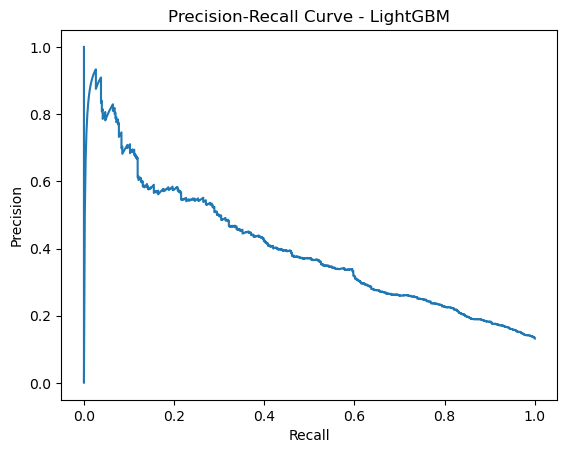

In [109]:
plt.plot(
    recall,
    precision
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - LightGBM"
         )
plt.show()

In [110]:
pr_auc = average_precision_score(
    y_test,
    final_probability
)
print("PR-AUC:",
      pr_auc)

PR-AUC: 0.40334141703380544


In [111]:
preprocessor_fitted = (
    best_lgbm.named_steps["preprocessor"]
        )

In [112]:
lgbm_fitted = (
    best_lgbm.named_steps["model"]
)

In [113]:
feature_names  =(
    preprocessor_fitted
    .get_feature_names_out())

In [114]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": (
        lgbm_fitted
        .feature_importances_
    )
})

In [115]:
importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

In [116]:
importance_df.head(15)

,Feature,Importance
9,num__Debt_to_Income_Ratio,546
7,num__Credit_Score,345
10,num__Loan_Amount,300
8,num__Savings_Balance,295
17,num__Credit_Card_Utilization,286
1,num__Employment_Years,266
4,num__Monthly_Income,253
3,num__Annual_Income,240
16,num__Late_Payments_12M,219
12,num__Interest_Rate,172


#### SHAP (SHapley Additive exPlanations)

In [119]:
import shap

In [118]:
X_test_transformed = (
    preprocessor_fitted
    .transform(X_test)
)

In [120]:
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

In [121]:
explainer = shap.TreeExplainer(
    lgbm_fitted
)

In [122]:
shap_values = explainer.shap_values(
    X_test_transformed
)

C:\Users\Dice\anaconda3\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [123]:
if isinstance(shap_values,list):
    shap_values_for_positive_class = shap_values[1]
else:
    shap_values_for_positive_class = shap_values

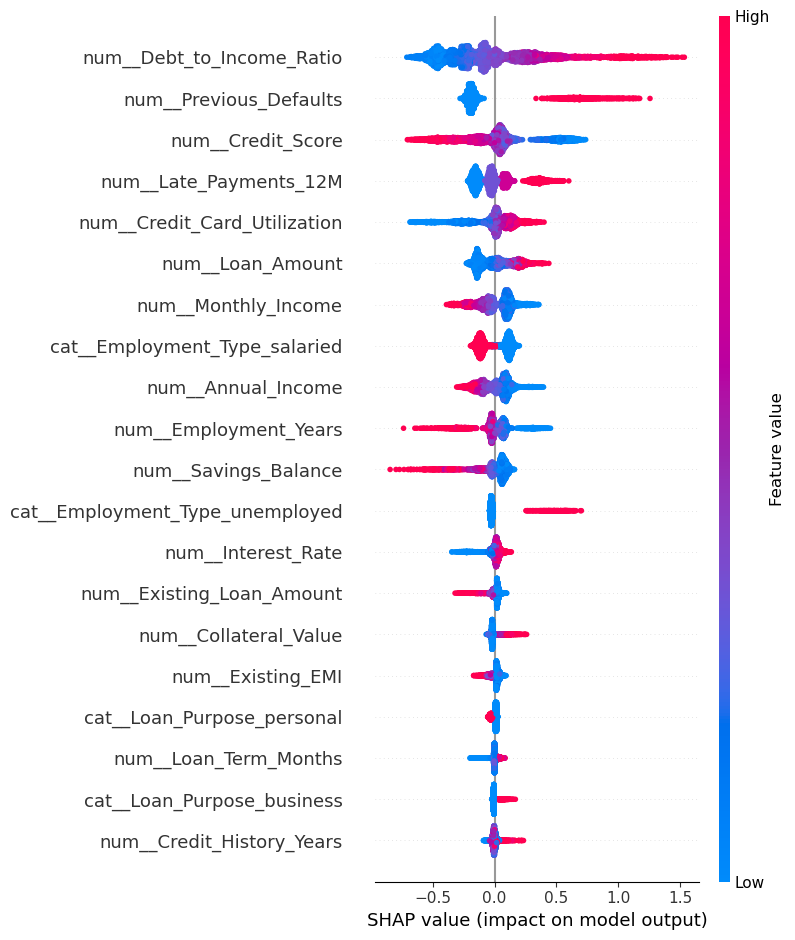

In [124]:
shap.summary_plot(
    shap_values_for_positive_class,
    X_test_transformed,
    feature_names=feature_names
)

##### For Customer 1

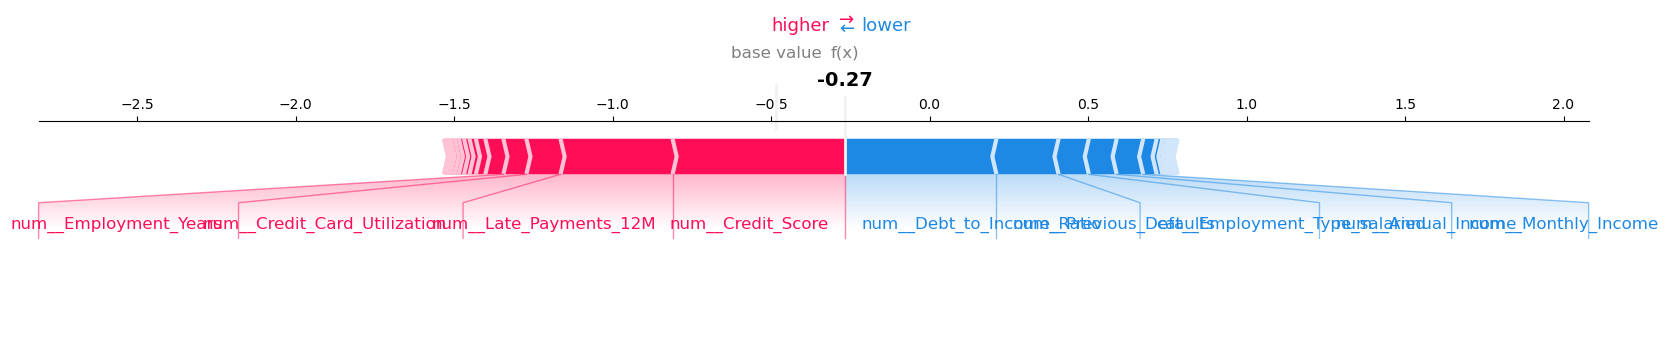

In [125]:
shap.force_plot(
    explainer.expected_value[1]
    if isinstance(explainer.expected_value,(list,np.ndarray))
    else explainer.expected_value,
    shap_values_for_positive_class[0],
    feature_names=feature_names,
    matplotlib=True
)

In [126]:
final_model = best_lgbm

In [127]:
final_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [128]:
final_probability = (
    final_model
    .predict_proba(X_test)[:,1]
)

In [129]:
final_prediction = (
    final_probability >= best_threshold
).astype(int)

In [130]:
print(classification_report(y_test,final_prediction))

              precision    recall  f1-score   support

           0       0.92      0.89      0.90      3471
           1       0.39      0.46      0.42       529

    accuracy                           0.83      4000
   macro avg       0.65      0.67      0.66      4000
weighted avg       0.85      0.83      0.84      4000



In [131]:
print("ROC-AUC:",
      roc_auc_score(
          y_test,
          final_probability
      )
     )
print("PR-AUC:",
      average_precision_score(
          y_test,
          final_probability
      )
     )

ROC-AUC: 0.7719168111258338
PR-AUC: 0.40334141703380544


### Save the model
* loan_default_model.pkl
* pkl : pickle can serialize python objects
* We can save Preprocessing+Model together
  > because our model is a Pipeline


In [132]:
import pickle

In [133]:
model_package = {
    "model": final_model,
    "threshold": best_threshold
}

In [134]:
with open(
    "loan_default_model.pkl",
    "wb"
) as file:
    pickle.dump(
        model_package,
        file
    )

In [135]:
with open(
    "loan_default_model.pkl",
    "rb"
) as file:
    saved_package = pickle.load(file)

In [136]:
loaded_model = saved_package["model"]
loaded_threshold = (
    saved_package["threshold"]
)

#### Now create a prediction system

In [137]:
def predict_loan_default(customer_data):

    probability = (
        loaded_model
        .predict_proba(customer_data)[:,1]
    )[0]
    prediction = int(
    probability >= loaded_threshold
    )
    if prediction == 1:
        result = "High Default Risk"
    else:
        result = "Low Default Risk"

    return {
    "Default Probability": probability,
    "Prediction": prediction,
    "Risk":result
    }

In [ ]:
result = predict_loan_default(
    new_customer
)
result

In [138]:
new_customer = pd.DataFrame({
    "Age": [29],
    "Employment_Type": ["self-employed"],
    "Employment_Years": [5],
    "Education": ["postgraduate"],
    "Dependents": [1],
    "Annual_Income": [950000],
    "Monthly_Income": [79000],
    "Existing_Loan_Amount": [250000],
    "Existing_EMI": [12000],
    "Credit_Score": [742],
    "Savings_Balance": [220000],
    "Debt_to_Income_Ratio": [0.28],
    "Loan_Amount": [600000],
    "Loan_Term_Months": [48],
    "Interest_Rate": [10.25],
    "Loan_Purpose": ["education"],
    "Collateral_Value": [850000],
    "Previous_Loan_Count": [1],
    "Previous_Defaults": [0],
    "Late_Payments_12M": [0],
    "Credit_Card_Utilization": [32],
    "Credit_History_Years": [7]
})

In [139]:
result = predict_loan_default(
    new_customer
)
result

{'Default Probability': np.float64(0.29006249175527066),
 'Prediction': 0,
 'Risk': 'Low Default Risk'}

In [140]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle
st.title("Loan Default Prediction")
model = pickle.load(open("loan_default_model.pkl","rb"))
st.write("Model loaded successfully")

Overwriting app.py


In [141]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
lightgbm
matplotlib
seaborn

Overwriting requirements.txt


In [142]:
%%writefile app.py

import streamlit as st
import pandas as pd
import pickle


# =========================================================
# PAGE CONFIGURATION
# =========================================================

st.set_page_config(
    page_title="Loan Default Prediction",
    page_icon="💳",
    layout="wide",
    initial_sidebar_state="collapsed"
)


# =========================================================
# LOAD MODEL
# =========================================================

with open("loan_default_model.pkl", "rb") as file:
    saved_package = pickle.load(file)

model = saved_package["model"]
threshold = saved_package["threshold"]


# =========================================================
# CUSTOM CSS
# =========================================================

st.markdown("""
<style>

.main {
    padding-top: 1rem;
}

.header {
    text-align: center;
    padding: 20px 0px 10px 0px;
}

.header h1 {
    font-size: 42px;
    margin-bottom: 5px;
}

.header p {
    font-size: 18px;
    color: #777777;
}

.section {
    font-size: 24px;
    font-weight: 600;
    margin-top: 20px;
    margin-bottom: 15px;
}

.result {
    padding: 25px;
    border-radius: 15px;
    text-align: center;
    margin-top: 25px;
}

</style>
""", unsafe_allow_html=True)


# =========================================================
# HEADER
# =========================================================

st.markdown("""
<div class="header">

<h1>💳 Loan Default Prediction</h1>

<p>
Predict the likelihood of loan default using a Machine Learning model
</p>

</div>
""", unsafe_allow_html=True)

st.divider()


# =========================================================
# APPLICATION FORM
# =========================================================

with st.form("loan_prediction_form"):

    # -----------------------------------------------------
    # PERSONAL INFORMATION
    # -----------------------------------------------------

    st.markdown(
        '<div class="section">👤 Personal Information</div>',
        unsafe_allow_html=True
    )

    col1, col2, col3 = st.columns(3)

    with col1:
        age = st.number_input(
            "Age",
            min_value=18,
            max_value=100,
            value=35,
            step=1
        )

    with col2:
        employment_type = st.selectbox(
            "Employment Type",
            [
                "salaried",
                "self-employed",
                "business",
                "contract",
                "unemployed"
            ]
        )

    with col3:
        employment_years = st.number_input(
            "Employment Years",
            min_value=0.0,
            max_value=50.0,
            value=5.0,
            step=1.0
        )

    col1, col2, col3 = st.columns(3)

    with col1:
        education = st.selectbox(
            "Education",
            [
                "graduate",
                "post-graduate",
                "high school",
                "diploma",
                "doctorate"
            ]
        )

    with col2:
        dependents = st.number_input(
            "Number of Dependents",
            min_value=0.0,
            max_value=10.0,
            value=1.0,
            step=1.0
        )

    with col3:
        credit_history_years = st.number_input(
            "Credit History (Years)",
            min_value=0,
            max_value=50,
            value=7,
            step=1
        )


    st.divider()


    # -----------------------------------------------------
    # FINANCIAL INFORMATION
    # -----------------------------------------------------

    st.markdown(
        '<div class="section">💰 Financial Information</div>',
        unsafe_allow_html=True
    )

    col1, col2, col3 = st.columns(3)

    with col1:
        annual_income = st.number_input(
            "Annual Income (₹)",
            min_value=0.0,
            value=750000.0,
            step=10000.0
        )

    with col2:
        monthly_income = st.number_input(
            "Monthly Income (₹)",
            min_value=0,
            value=62500,
            step=1000
        )

    with col3:
        savings_balance = st.number_input(
            "Savings Balance (₹)",
            min_value=0.0,
            value=150000.0,
            step=10000.0
        )

    col1, col2, col3 = st.columns(3)

    with col1:
        existing_loan_amount = st.number_input(
            "Existing Loan Amount (₹)",
            min_value=0.0,
            value=0.0,
            step=10000.0
        )

    with col2:
        existing_emi = st.number_input(
            "Existing EMI (₹)",
            min_value=0.0,
            value=0.0,
            step=1000.0
        )

    with col3:
        debt_to_income_ratio = st.number_input(
            "Debt-to-Income Ratio",
            min_value=0.0,
            max_value=3.0,
            value=0.40,
            step=0.01
        )


    st.divider()


    # -----------------------------------------------------
    # LOAN INFORMATION
    # -----------------------------------------------------

    st.markdown(
        '<div class="section">🏦 Loan Information</div>',
        unsafe_allow_html=True
    )

    col1, col2, col3 = st.columns(3)

    with col1:
        loan_amount = st.number_input(
            "Loan Amount (₹)",
            min_value=0.0,
            value=750000.0,
            step=10000.0
        )

    with col2:
        loan_term_months = st.number_input(
            "Loan Term (Months)",
            min_value=12,
            max_value=300,
            value=48,
            step=12
        )

    with col3:
        interest_rate = st.number_input(
            "Interest Rate (%)",
            min_value=0.0,
            max_value=30.0,
            value=11.5,
            step=0.1
        )

    col1, col2 = st.columns(2)

    with col1:
        loan_purpose = st.selectbox(
            "Loan Purpose",
            [
                "personal",
                "home",
                "auto",
                "education",
                "business",
                "medical"
            ]
        )

    with col2:
        collateral_value = st.number_input(
            "Collateral Value (₹)",
            min_value=0.0,
            value=0.0,
            step=10000.0
        )


    st.divider()


    # -----------------------------------------------------
    # CREDIT & REPAYMENT HISTORY
    # -----------------------------------------------------

    st.markdown(
        '<div class="section">📊 Credit & Repayment History</div>',
        unsafe_allow_html=True
    )

    col1, col2, col3 = st.columns(3)

    with col1:
        credit_score = st.number_input(
            "Credit Score",
            min_value=300,
            max_value=900,
            value=720,
            step=1
        )

    with col2:
        previous_loan_count = st.number_input(
            "Previous Loan Count",
            min_value=0,
            max_value=20,
            value=1,
            step=1
        )

    with col3:
        previous_defaults = st.number_input(
            "Previous Defaults",
            min_value=0,
            max_value=10,
            value=0,
            step=1
        )

    col1, col2 = st.columns(2)

    with col1:
        late_payments_12m = st.number_input(
            "Late Payments (Last 12 Months)",
            min_value=0,
            max_value=20,
            value=0,
            step=1
        )

    with col2:
        credit_card_utilization = st.number_input(
            "Credit Card Utilization",
            min_value=0.0,
            max_value=1.0,
            value=0.40,
            step=0.01
        )


    st.write("")

    # -----------------------------------------------------
    # PREDICTION BUTTON
    # -----------------------------------------------------

    submitted = st.form_submit_button(
        "🔍 Predict Loan Default",
        type="primary",
        use_container_width=True
    )


# =========================================================
# PREDICTION
# =========================================================

if submitted:

    # Create dataframe with EXACT model feature names

    input_data = pd.DataFrame({
        "Age": [age],
        "Employment_Type": [employment_type],
        "Employment_Years": [employment_years],
        "Education": [education],
        "Dependents": [dependents],
        "Annual_Income": [annual_income],
        "Monthly_Income": [monthly_income],
        "Existing_Loan_Amount": [existing_loan_amount],
        "Existing_EMI": [existing_emi],
        "Credit_Score": [credit_score],
        "Savings_Balance": [savings_balance],
        "Debt_to_Income_Ratio": [debt_to_income_ratio],
        "Loan_Amount": [loan_amount],
        "Loan_Term_Months": [loan_term_months],
        "Interest_Rate": [interest_rate],
        "Loan_Purpose": [loan_purpose],
        "Collateral_Value": [collateral_value],
        "Previous_Loan_Count": [previous_loan_count],
        "Previous_Defaults": [previous_defaults],
        "Late_Payments_12M": [late_payments_12m],
        "Credit_Card_Utilization": [credit_card_utilization],
        "Credit_History_Years": [credit_history_years]
    })


    # -----------------------------------------------------
    # MODEL PREDICTION
    # -----------------------------------------------------

    probability = model.predict_proba(input_data)[0][1]

    prediction = int(probability >= threshold)

    probability_percentage = probability * 100


    # -----------------------------------------------------
    # RESULT
    # -----------------------------------------------------

    st.divider()

    st.markdown(
        '<div class="section">📋 Prediction Result</div>',
        unsafe_allow_html=True
    )


    if prediction == 1:

        st.error(
            f"⚠️ HIGHER DEFAULT RISK\n\n"
            f"Estimated probability of default: "
            f"{probability_percentage:.2f}%"
        )

    else:

        st.success(
            f"✅ LOWER DEFAULT RISK\n\n"
            f"Estimated probability of default: "
            f"{probability_percentage:.2f}%"
        )


    st.progress(
        min(int(probability_percentage), 100)
    )


    st.caption(
        f"Classification threshold used by the model: {threshold:.2f}"
    )

Overwriting app.py


In [1]:
import os
print(os.getcwd())

C:\Users\Dice\Loan_Default_Project.7b69a749-14c2-4de8-a4b1-2350f97edf28\Loan_Default_Project
